# ***2 практика*** / Байкалов Сергей Андреевич / 925-М


Задание 1. Выявление мультиколлинеарности
Найдите все пары признаков с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: Признак_1, Признак_2, Корреляция. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

Ответ: Найдено 2 пары с |r| > 0.7:

1) otal_phenols и flavanoids

2) flavanoids и od280/od315_of_diluted_wines

In [3]:
# фиксированное случайное число
import numpy as np
np.random.seed(42)

# датасет wine
from sklearn.datasets import load_wine

# библиотека pandas
import pandas as pd

# загрузка датасета
wine = load_wine()

# таблица признаков
df_wine = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# столбец с регионами
df_wine["region"] = [
    f"Region_{t+1}"
    for t in wine.target
]

# размер датасета
print("Датасет Wine:", df_wine.shape)

# таблица корреляций
corr = df_wine.drop(columns=["region"]).corr()

# список названий признаков
columns = corr.columns

# список сильных корреляций
strong_corr = []

# перебор всех признаков
for i in range(len(columns)):

    # перебор следующих признаков
    for j in range(i + 1, len(columns)):

        # текущая корреляция
        value = corr.iloc[i, j]

        # проверка на сильную корреляцию
        if abs(value) > 0.7:

            # сохранение результата
            strong_corr.append(
                (
                    columns[i],
                    columns[j],
                    value
                )
            )

print("Признак 1\t\tПризнак 2\t\tКорреляция")

for feature1, feature2, value in strong_corr:
    print(
        f"{feature1:20} {feature2:25} {value:.3f}"
    )

Датасет Wine: (178, 14)
Признак 1		Признак 2		Корреляция
total_phenols        flavanoids                0.865
flavanoids           od280/od315_of_diluted_wines 0.787


Задание 2. Анализ асимметрии распределений
Рассчитайте коэффициент асимметрии (skewness) для каждого признака с помощью scipy.stats.skew(). Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

Ответ: Признаки с наибольшей положительной асимметрией:

1) magnesium:  1.089

2) malic_acid: 1.031

3) color_intensity: 0.861

Ядро RBF вычисляет расстояния в исходном признаковом пространстве и предполагает, что признаки распределены примерно нормально. Признаки с сильной положительной асимметрией нарушают это предположение:
1) Большие редкие значения создают аномально большие расстояния в пространстве ядра

2) Это искажает решающую границу и снижает точность классификации

In [5]:
# функция для расчета асимметрии
from scipy.stats import skew

# числовые признаки
numeric_df = df_wine.drop(columns=["region"])

# асимметрия признаков
skew_values = numeric_df.skew()

# список значений асимметрии
skew_list = []

# перенос данных в список
for column in skew_values.index:

    skew_list.append(
        (
            column,
            skew_values[column]
        )
    )

# сортировка по убыванию асимметрии
skew_list.sort(
    key=lambda x: x[1],
    reverse=True
)

# три самых больших значения
top_3 = skew_list[:3]

# заголовок результатов
print("топ-3 признака по асимметрии:\n")

# вывод результатов
for name, value in top_3:

    print(
        name,
        "-",
        round(value, 3)
    )

топ-3 признака по асимметрии:

magnesium - 1.098
malic_acid - 1.04
color_intensity - 0.869


Задание 3. Создание «идеального» разделяющего признака
Сконструируйте новый признак как линейную комбинацию двух существующих:
wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']

Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт коэффициента разделения классов (разница средних / сумма стандартных отклонений).

Ответ: WQI лучше разделяет Region_1 и Region_2, чем оба исходных признака по отдельности, однако для пары Region_1 vs Region_3 признак flavanoids превосходит WQI.
Это объясняется тем, что color_intensity у Region_1 и Region_3 схожа, а flavanoids — разные.

коэффициент разделения классов

Region_1 и Region_2: 1.124
Region_1 и Region_3: 0.339
Region_2 и Region_3: 0.568

статистика Region_1
count    59.000000
mean      4.000746
std       0.691067
min       2.894000
25%       3.428000
50%       3.896000
75%       4.369000
max       5.838000
Name: wine_quality_index, dtype: float64

статистика Region_2
count    71.000000
mean      2.483155
std       0.659371
min       1.122000
25%       2.084000
50%       2.402000
75%       2.711000
max       5.448000
Name: wine_quality_index, dtype: float64

статистика Region_3
count    48.000000
mean      3.427375
std       1.002467
min       1.822000
25%       2.538000
50%       3.417000
75%       4.162000
max       5.986000
Name: wine_quality_index, dtype: float64


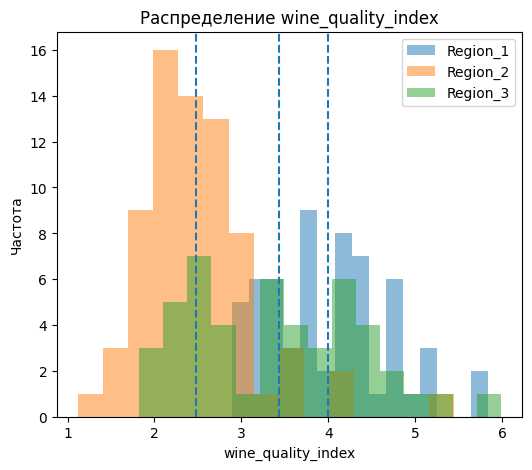

In [9]:
import matplotlib.pyplot as plt
# новый показатель качества вина
df_wine["wine_quality_index"] = (
    0.6 * df_wine["flavanoids"] +
    0.4 * df_wine["color_intensity"]
)

# данные первого региона
region1 = df_wine[
    df_wine["region"] == "Region_1"
]["wine_quality_index"]

# данные второго региона
region2 = df_wine[
    df_wine["region"] == "Region_2"
]["wine_quality_index"]

# данные третьего региона
region3 = df_wine[
    df_wine["region"] == "Region_3"
]["wine_quality_index"]

# среднее значение для первого региона
mean1 = region1.mean()

# среднее значение для второго региона
mean2 = region2.mean()

# среднее значение для третьего региона
mean3 = region3.mean()

# стандартное отклонение для первого региона
std1 = region1.std()

# стандартное отклонение для второго региона
std2 = region2.std()

# стандартное отклонение для третьего региона
std3 = region3.std()

# коэффициент разделения region1 и region2
sep12 = abs(mean1 - mean2) / (std1 + std2)

# коэффициент разделения region1 и region3
sep13 = abs(mean1 - mean3) / (std1 + std3)

# коэффициент разделения region2 и region3
sep23 = abs(mean2 - mean3) / (std2 + std3)

# результаты разделения
print("коэффициент разделения классов")
print()

print("Region_1 и Region_2:", round(sep12, 3))
print("Region_1 и Region_3:", round(sep13, 3))
print("Region_2 и Region_3:", round(sep23, 3))

# статистика первого региона
print()
print("статистика Region_1")
print(region1.describe())

# статистика второго региона
print()
print("статистика Region_2")
print(region2.describe())

# статистика третьего региона
print()
print("статистика Region_3")
print(region3.describe())

# окно графика
plt.figure(figsize=(6, 5))

# гистограмма первого региона
plt.hist(
    region1,
    bins=15,
    alpha=0.5,
    label="Region_1"
)

# гистограмма второго региона
plt.hist(
    region2,
    bins=15,
    alpha=0.5,
    label="Region_2"
)

# гистограмма третьего региона
plt.hist(
    region3,
    bins=15,
    alpha=0.5,
    label="Region_3"
)

# среднее первого региона
plt.axvline(mean1, linestyle="--")

# среднее второго региона
plt.axvline(mean2, linestyle="--")

# среднее третьего региона
plt.axvline(mean3, linestyle="--")

# подпись оси x
plt.xlabel("wine_quality_index")

# подпись оси y
plt.ylabel("Частота")

# заголовок графика
plt.title("Распределение wine_quality_index")

# легенда
plt.legend()

# отображение графика
plt.show()